In [3]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

from src.scp_core import SCP
from experiments.targets import Banana_t, skewt, skewCauchy, CauchyDifference, funnel_t

In [5]:
# set up target
d = 10
# df = 10
# target = CauchyDifference(d, lbd=2)
df1 = 1.2
df2 = 2
target = skewt(a=jnp.linspace(df1/2, df2/2, d), b=jnp.linspace(df2/2, df1/2, d))
# target = funnel_t(d, df=df)
# target = skewCauchy(jnp.linspace(-0.5, 0.5, d))
# target = Banana_t(d=d, df=df)

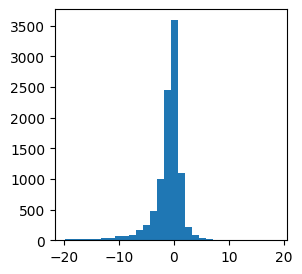

In [6]:
exact_samples = target.sample(seed=0, n=10000)

plt.figure(figsize=(3, 3))
plt.hist(exact_samples[abs(exact_samples[:, 0]) < 20, 0], 30)
plt.show()

In [7]:
scp_model = SCP(d, latitude=1.5) # set up SCP class
opt_params, losses = scp_model.minimize_reverse_kl(target.log_prob, seed=0, ntrain=2000, learning_rate=0.01) # optimize parameters

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 2637.67it/s]


Text(0.5, 1.0, 'KL divergence vs training steps')

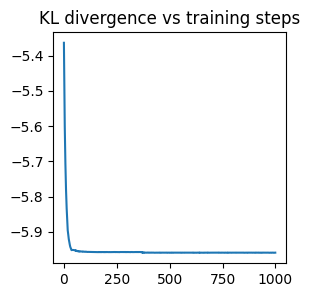

In [8]:
plt.figure(figsize=(3, 3))
plt.plot(losses)
plt.title('KL divergence vs training steps')

In [16]:
# run MCMC
samples, accept_prob = scp_model.rwm_bright_side(target.log_prob, opt_params, seed=1, stepsize=.1, nsample=10_000_000, thinning=1_000, algo='stepout')
print('Acceptance rate:', accept_prob)

Running for 10,000,100 iterations: 100%|██████████| 10000100/10000100 [01:41<00:00, 98713.12it/s]

Acceptance rate: 0.48529997


(-20.0, 20.0)

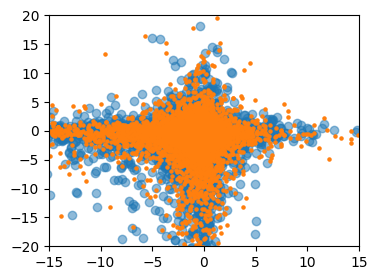

In [17]:
exact_samples = target.sample(seed=1, n=samples.shape[0])
plt.figure(figsize=(4, 3))
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5)
plt.scatter(samples[:, 0], samples[:, 1], s=5)
plt.xlim(-15, 15)
plt.ylim(-20, 20)

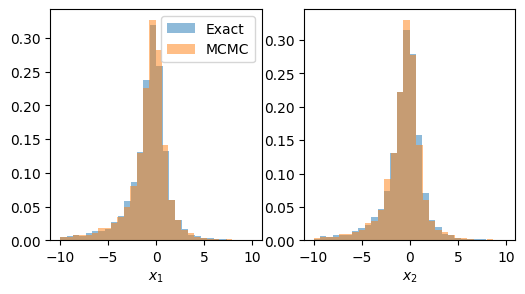

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for i in [0, 1]:
    ax[i].hist(exact_samples[abs(exact_samples[:, i]) < 10, i], bins=30, density=True, alpha=0.5, label='Exact')
    ax[i].hist(samples[abs(samples[:, i]) < 10, i], bins=30, density=True, alpha=0.5, label='MCMC')
    ax[i].set_xlabel(f'$x_{i+1}$')
ax[0].legend()

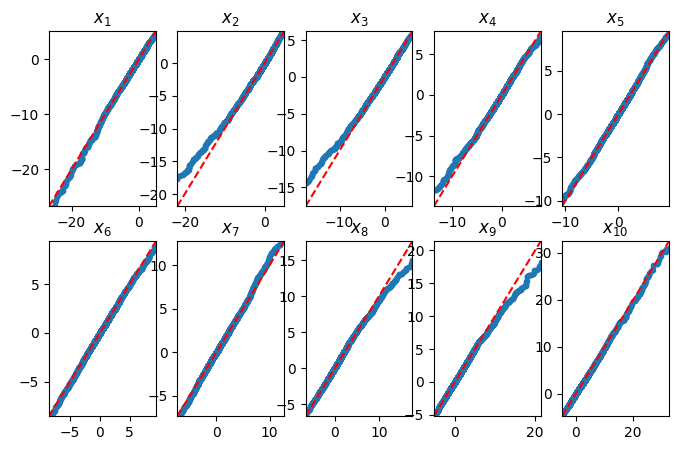

In [19]:
fig, ax = plt.subplots(2, 5, figsize=(8, 5))
for i in range(2):
    for j in range(5):
        k = i * 5 + j
        exact_sorted = jnp.sort(exact_samples[:, k])
        mcmc_sorted = jnp.sort(samples[:, k])
        ax[i, j].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
        qs = jnp.quantile(exact_samples[:, k], jnp.array([0.01, 0.99]))
        ax[i, j].set_xlim(qs)
        ax[i, j].set_ylim(qs)
        ax[i, j].plot(qs, qs, 'r--')  # Reference line for y=x
        ax[i, j].set_title(f'$x_{{{k+1}}}$')


In [13]:
samples, accept_prob = scp_model.rwm_bright_side(target.log_prob, opt_params, seed=1, stepsize=.1, nsample=10_000_000, thinning=1000, algo='reject')
print('Acceptance rate:', accept_prob)

Running for 10,000,100 iterations: 100%|██████████| 10000100/10000100 [01:37<00:00, 102460.70it/s]


Acceptance rate: 0.4856


In [14]:
exact_samples = target.sample(seed=1, n=samples.shape[0])

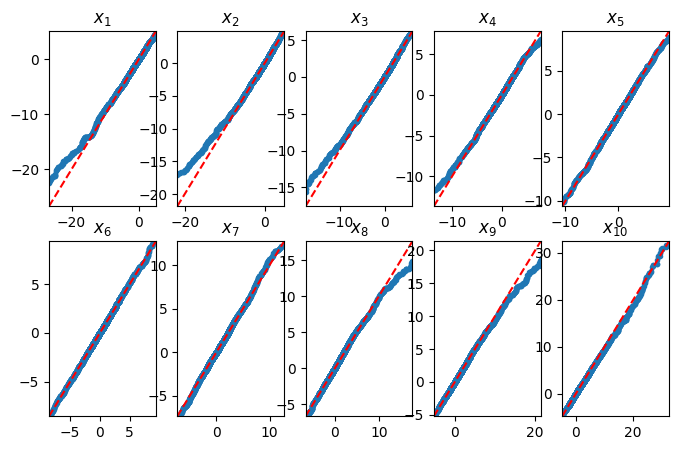

In [15]:
fig, ax = plt.subplots(2, 5, figsize=(8, 5))
for i in range(2):
    for j in range(5):
        k = i * 5 + j
        exact_sorted = jnp.sort(exact_samples[:, k])
        mcmc_sorted = jnp.sort(samples[:, k])
        ax[i, j].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
        qs = jnp.quantile(exact_samples[:, k], jnp.array([0.01, 0.99]))
        ax[i, j].set_xlim(qs)
        ax[i, j].set_ylim(qs)
        ax[i, j].plot(qs, qs, 'r--')  # Reference line for y=x
        ax[i, j].set_title(f'$x_{{{k+1}}}$')